# Exercise: Catchment delineation, geospatial tools to retrieve site information, automated data collection, and visualization 

Use the [USGS NWIS mapper system](https://apps.usgs.gov/nwismapper/) to identify a NWIS id with high eleveation SNOTEL sites in the Great Salt Lake Basin. Feel free to work backwards and use the [ USDA NRCS SNOTELinteractive map system](https://nwcc-apps.sc.egov.usda.gov/imap/#version=2&elements=&networks=!&states=!&counties=!&hucs=&minElevation=&maxElevation=&elementSelectType=any&activeOnly=true&activeForecastPointsOnly=true&hucLabels=false&hucIdLabels=false&hucParameterLabels=true&stationLabels=&overlays=&hucOverlays=&basinOpacity=75&basinNoDataOpacity=25&basemapOpacity=100&maskOpacity=0&mode=data&openSections=dataElement,parameter,date,basin,options,elements,location,networks&controlsOpen=true&popup=&popupMulti=&popupBasin=&base=esriNgwm&displayType=station&basinType=6&dataElement=WTEQ&depth=-8&parameter=PCTMED&frequency=DAILY&duration=I&customDuration=&dayPart=E&monthPart=E&forecastPubDay=1&forecastExceedance=50&useMixedPast=true&seqColor=1&divColor=7&scaleType=D&scaleMin=&scaleMax=&referencePeriodType=POR&referenceBegin=1991&referenceEnd=2020&minimumYears=20&hucAssociations=true&relativeDate=-1&lat=42.300&lon=-114.300&zoom=4.5) to find a basin upstream of a NWIS site that has 3-4 Snotel sites.

Conduct/repeat the following activities in a new notebook that you create, called: **My_SNOTEL_Analysis.ipynb**:
1. Create a delineated Watershed Map for the area upstream of the NWIS site
2. Retrieve data for the selected sites
3. Process the data to enable plotting and analysis
4. Make a snow report for WY2026
5. Generate a Basin Snow report

*note, make sure you correctly name any files for your particlular watershed of interest


In [8]:
from pynhd import NLDI, WaterData, NHDPlusHR, GeoConnex
import geopandas as gpd
import pandas as pd
from supporting_scripts import getData, SNOTEL_Analyzer, dataprocessing, mapping
from shapely.geometry import box, Polygon
import os
import datetime
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")
import importlib.util
importlib.reload(dataprocessing)

<module 'supporting_scripts.dataprocessing' from '/uufs/chpc.utah.edu/common/home/u0972368/Hydroinformatics/Data-Acquisition-Processing-Analysis/supporting_scripts/dataprocessing.py'>

Define Site/Basin

In [2]:
nldi = NLDI()
usgs_gage_id = "09359500"# NWIS id for Animas River at Durango, CO
WY = 2026 # Water Year to analyze. A water year is defined as the 12 month period from October 1st to September 30th.

Collect Watershed Size

In [3]:
nldi = NLDI()

#Getting basin geometry
print('Collecting basins...', end='')
basin = nldi.get_basins(usgs_gage_id)
if not os.path.exists('files'):
    os.makedirs('files')
basin.to_file("files/TuolumneRiverBasin.shp")
print('done')

site_feature = nldi.getfeature_byid("nwissite", f"USGS-{usgs_gage_id}")
upstream_network = nldi.navigate_byid(
    "nwissite", f"USGS-{usgs_gage_id}", "upstreamMain", "flowlines", distance=9999
)

Create Map

In [4]:
# create map, having trouble showigng the map? Does "Make this Notebook Trusted to load map" appear?
#cd to the directy and run jupyter trust Snotel.ipynb
mapping.basin_mapping(basin, site_feature)

Identify SNOTEL Sites

In [5]:
# Create geodataframe of all stations
all_stations_gdf = gpd.read_file('https://raw.githubusercontent.com/egagli/snotel_ccss_stations/main/all_stations.geojson').set_index('code')
all_stations_gdf = all_stations_gdf[all_stations_gdf['csvData']==True]

# Use the polygon geometry to select snotel sites that are within the domain
gdf_in_bbox = all_stations_gdf[all_stations_gdf.geometry.within(basin.geometry[0])]

#reset index to have siteid as a column
gdf_in_bbox.reset_index(drop=False, inplace=True)

#make begin and end date a str
gdf_in_bbox['beginDate'] = [datetime.datetime.strftime(gdf_in_bbox['beginDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox['endDate'] = [datetime.datetime.strftime(gdf_in_bbox['endDate'][i], "%Y-%m-%d") for i in np.arange(0,len(gdf_in_bbox),1)]
gdf_in_bbox

,code,name,network,elevation_m,latitude,longitude,state,HUC,mgrs,mountainRange,beginDate,endDate,csvData,geometry
0,386_CO_SNTL,Cascade,SNOTEL,2706.624023,37.650829,-107.806023,Colorado,140801040201,13SBB,Southern Rocky Mountains,1978-10-01,2022-09-27,True,POINT (-107.80602 37.65083)
1,387_CO_SNTL,Cascade #2,SNOTEL,2718.815918,37.658001,-107.802681,Colorado,140801040201,13SBB,Southern Rocky Mountains,1990-09-30,2026-03-05,True,POINT (-107.80268 37.658)
2,629_CO_SNTL,Mineral Creek,SNOTEL,3060.191895,37.847469,-107.726570,Colorado,140801040103,13SBB,Southern Rocky Mountains,1978-10-01,2026-03-05,True,POINT (-107.72657 37.84747)
3,632_CO_SNTL,Molas Lake,SNOTEL,3200.399902,37.749321,-107.688660,Colorado,140801040302,13SBB,Southern Rocky Mountains,1985-10-01,2026-03-05,True,POINT (-107.68866 37.74932)
4,713_CO_SNTL,Red Mountain Pass,SNOTEL,3413.760010,37.891800,-107.713417,Colorado,140801040103,13SBB,Southern Rocky Mountains,1979-10-01,2026-03-05,True,POINT (-107.71342 37.8918)
5,780_CO_SNTL,Spud Mountain,SNOTEL,3249.167969,37.698662,-107.777153,Colorado,140801040202,13SBB,Southern Rocky Mountains,1985-10-01,2026-03-05,True,POINT (-107.77715 37.69866)


Map SNOTEL Sites too

In [6]:
mapping.snotel_mapping(gdf_in_bbox, basin, site_feature)

Retreive Data

In [7]:
# Use the getData module to retrieve data 
OutputFolder = 'files/SNOTEL'

StateAbb = 'CO'

if not os.path.exists(OutputFolder):
    os.makedirs(OutputFolder)

for i in gdf_in_bbox.index:
    #getData.getCoSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i], gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)
    getData.getSNOTELData(gdf_in_bbox.name[i], gdf_in_bbox.code[i] , StateAbb, gdf_in_bbox.beginDate[i], gdf_in_bbox.endDate[i], OutputFolder)


Start retrieving data for Cascade, 386_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/386:CO:SNTL%7Cid=%22%22%7Cname/1978-10-01,2022-09-27/WTEQ::value?fitToScreen=false
Start retrieving data for Cascade #2, 387_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/387:CO:SNTL%7Cid=%22%22%7Cname/1990-09-30,2026-03-05/WTEQ::value?fitToScreen=false
Start retrieving data for Mineral Creek, 629_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/629:CO:SNTL%7Cid=%22%22%7Cname/1978-10-01,2026-03-05/WTEQ::value?fitToScreen=false
Start retrieving data for Molas Lake, 632_CO_SNTL 
 https://wcc.sc.egov.usda.gov/reportGenerator/view_csv/customMultiTimeSeriesGroupByStationReport/daily/start_of_period/632:CO:SNTL%7Cid=%22%22%7Cname/1985-10-01,2026-03-05/WTEQ::value?fitToS

Look at data

In [16]:
# Load the data for one site
sites = list(gdf_in_bbox.code)
stateab = 'CO'
sitedict = dict()

for site in sites:
    sitedict[site] = dataprocessing.processSNOTEL(site, stateab, WY)

sitedict[sites[0]].head()

386_CO_SNTL
Dropping 2026 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
2026 not found in the data, not dropping any columns
387_CO_SNTL
Dropping 2026 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
629_CO_SNTL
Dropping 2026 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
632_CO_SNTL
Dropping 2026 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
713_CO_SNTL
Dropping 2026 from the calculations of the min, mean, median, max SWE for each day of the water year across all other years of data available for that site
780_CO_SNTL
Dropping 2026 from the calculations of the min, mean, median, max SWE for each day of the water

,M,D,1979_SWE_in,1980_SWE_in,1981_SWE_in,1982_SWE_in,1983_SWE_in,1984_SWE_in,1985_SWE_in,1986_SWE_in,...,2022_SWE_in,min,Q10,Q25,mean,median,Q75,Q90,max,date
M-D,,,,,,,,,,,,,,,,,,,,,
10-01,10,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.239130,0.0,0.0,0.0,10.0,2023-10-01
10-02,10,2,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,...,0.0,0.0,0.0,0.0,0.263043,0.0,0.0,0.0,10.0,2023-10-02
10-03,10,3,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,...,0.0,0.0,0.0,0.0,0.284783,0.0,0.0,0.0,10.0,2023-10-03
10-04,10,4,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.341304,0.0,0.0,0.2,10.0,2023-10-04
10-05,10,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.363043,0.0,0.0,0.3,10.0,2023-10-05


Plot it!

TypeError: unsupported operand type(s) for /: 'NoneType' and 'float'

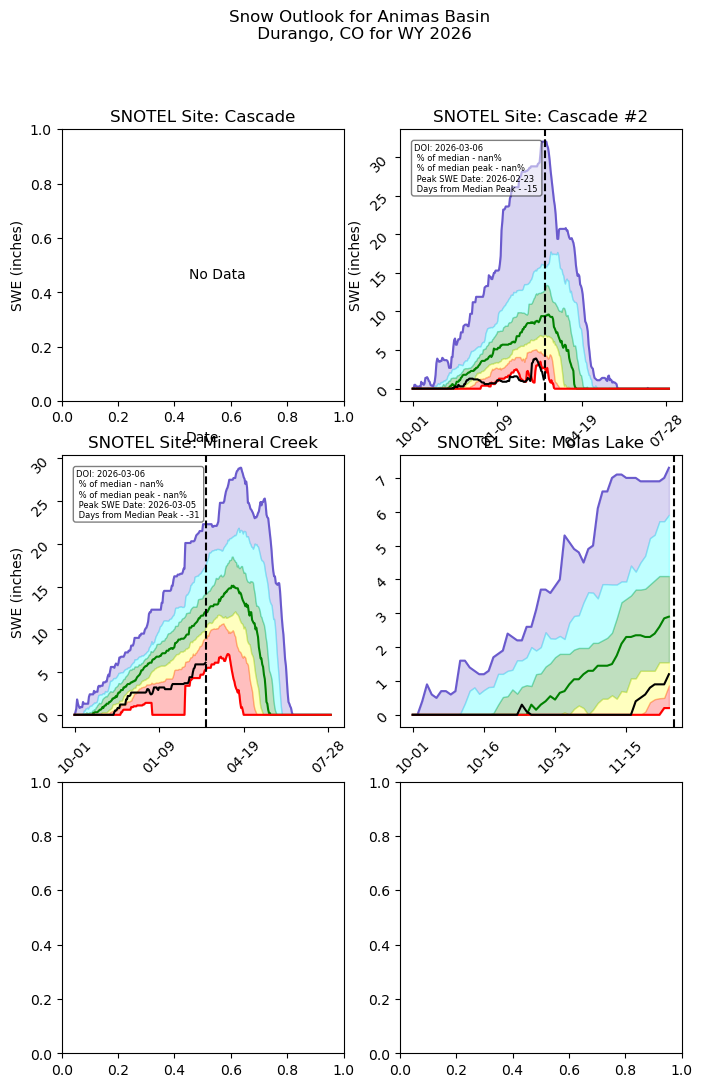

In [17]:
watershed = "Animas"
AOI = 'Durango, CO'
DOI = '03-06' #must be in MM-DD form
SNOTEL_Analyzer.SNOTELPlots(sitedict, gdf_in_bbox, WY, watershed, AOI,DOI)